In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage


In [17]:
load_dotenv()

False

In [ ]:
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [19]:
generate_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)
evaluator_llm = ChatGroq(
    model="llama-3.3-70b-versatile",   
    temperature=0
)
optimizer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",   
    temperature=0
)

In [20]:
from pydantic import BaseModel, Field
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","need_improvement"] = Field(description="The evaluation of the tweet")
    feedback: str = Field(description="Feedback for improving the tweet if the evaluation is 'need_improvement'")

In [21]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [22]:
#state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","need_improvement"]
    feedback: str
    iteration: int
    max_iterations: int

In [23]:
def generate_tweet(state: TweetState) -> TweetState:

    message = [
        SystemMessage(
            content="You are a social media manager. Your task is to create a tweet based on the given topic. The tweet should be engaging and relevant to the topic."
        ),

        HumanMessage(
            content=f"""
Write a tweet about the topic: {state['topic']}

Rules:
- The tweet should be less than 280 characters.
- The tweet should be engaging and relevant to the topic.
- The tweet should not contain any hashtags or mentions.
- This version is {state['iteration'] + 1} out of {state['max_iterations']}.
"""
        )
    ]

    response = generate_llm.invoke(message).content
    return {'tweet': response}

def evaluate_tweet(state: TweetState) -> TweetState:
    message = [
        SystemMessage(
            content="You are a senior social media manager. Your task is to evaluate the given tweet based on the topic. Provide feedback on how to improve the tweet if necessary."
        ),

        HumanMessage(
            content=f"""Evaluate the following tweet based on the topic: {state['topic']}

Tweet: {state['tweet']}
Auto Reject Criteria:
- The tweet is not relevant to the topic.
- The tweet is not engaging.
- Tweet exceeds 280 characters.
"""
        )
    ]

    response = structured_evaluator_llm.invoke(message)
    return {'evaluation':response.evaluation,'feedback': response.feedback}

def optimize_tweet(state: TweetState) -> TweetState:
    message = [
        SystemMessage(
            content="You are a social media manager. Your task is to optimize the given tweet based on the feedback provided. Use the feedback to improve the tweet while ensuring it remains engaging and relevant to the topic."
        ),

        HumanMessage(
            content=f"""Optimize the following tweet based on the topic and feedback:
Topic: {state['topic']}
Feedback: {state['feedback']}
Tweet: {state['tweet']}
"""
        )
    ]

    response = optimizer_llm.invoke(message).content
    iteration = state['iteration'] + 1
    return {'tweet': response, 'iteration': iteration}

In [24]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved':
        return END
    elif state['iteration'] >= state['max_iterations'] - 1:
        return END
    else:
        return 'optimize'

In [28]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation)

graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

In [29]:
initial_state = {
    "topic": "India's space program",
    "iteration": 1,
    "max_iterations": 5
}

workflow.invoke(initial_state)

{'topic': "India's space program",
 'tweet': '"India\'s space program is reaching new heights with innovative missions and cutting-edge technology, making the country a major player in space exploration."',
 'evaluation': 'approved',
 'feedback': "The tweet is relevant, engaging, and within the character limit, making it a well-crafted post that effectively highlights India's achievements in space exploration.",
 'iteration': 1,
 'max_iterations': 5}

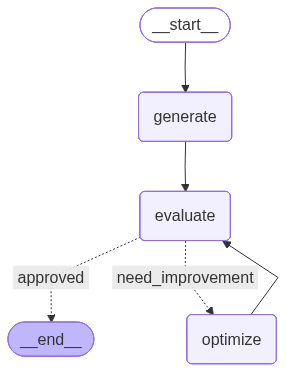

In [27]:
workflow